In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

def install_java():
  !apt update -qq
  !apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
  !java -version

install_java()

6 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


In [3]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.1 MB/s eta 0:00:00


In [4]:
!pip install py_vncorenlp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.7 MB/s eta 0:00:00
  Created wheel for py_vncorenlp: filename=py_vncorenlp-0.1.4-py3-none-any.whl size=4304 sha256=82b16719b4826e3535767b7168de7c1b985666ae0181173290b99f9d77733f0c
  Stored in directory: /root/.cache/pip/wheels/db/e5/ff/f4a1b4ece36e8582db1ca71150a34e987e65df50c35974e9bb
Successfully built py_vncorenlp


In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import os
import numpy as np

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def load_jsonl(filename):
    data = []
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                data.append(json.loads(line))
        return pd.DataFrame(data)
    except FileNotFoundError:
        print(f"Warning: {filename} not found.")
        return None

# Load the available file
dataset_path = "/content/drive/MyDrive/KLTN_Project/Datasets/filtered_queries"
df_keyword = load_jsonl(f'{dataset_path}/keyword.jsonl')
df_natural = load_jsonl(f'{dataset_path}/natural.jsonl')
df_semantic = load_jsonl(f'{dataset_path}/semantic.jsonl')
# -----------------------------------------------------------------

# Add labels
df_keyword['label'] = 'keyword'
df_natural['label'] = 'natural'
df_semantic['label'] = 'semantic'

# Combine into one DataFrame for analysis
df_all = pd.concat([df_keyword, df_natural, df_semantic], ignore_index=True)

# Extract actual text from the nested 'query' dictionary
df_all['text'] = df_all['query'].apply(lambda x: x['query'] if isinstance(x, dict) else "")

In [6]:
import os
import matplotlib.pyplot as plt

# Cấu hình thư mục xuất ảnh
EXPORT_DIR = '/content/drive/MyDrive/KLTN_Project/Results/charts'

if not os.path.exists(EXPORT_DIR):
    os.makedirs(EXPORT_DIR)
    print(f"Đã tạo thư mục: {EXPORT_DIR}")
else:
    print(f"Thư mục lưu trữ: {EXPORT_DIR}")

def save_chart(filename):
    """Hàm hỗ trợ lưu biểu đồ vào thư mục định sẵn"""
    path = os.path.join(EXPORT_DIR, filename)
    plt.savefig(path, bbox_inches='tight', dpi=300)
    print(f">> Đã lưu biểu đồ: {path}")

Thư mục lưu trữ: /content/drive/MyDrive/KLTN_Project/Results/charts


# Thống kê tổng quan

File: /content/drive/MyDrive/KLTN_Project/Datasets/vifc.csv - Rows: 34811

========== OVERALL STATISTICS ==========
Total Rows:    34811
Total Columns: 5

========== COLUMN INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34811 entries, 0 to 34810
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  34811 non-null  int64 
 1   document    34811 non-null  object
 2   evidence    34811 non-null  object
 3   query       34811 non-null  object
 4   id          34811 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.3+ MB
None

========== UNIQUE ELEMENTS PER COLUMN ==========
Unnamed: 0    34811
document       3030
evidence      15788
query         34703
id            34811
dtype: int64


/tmp/ipython-input-2588665335.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='pastel')


>> Đã lưu biểu đồ: /content/drive/MyDrive/KLTN_Project/Results/charts/overview_counts.png


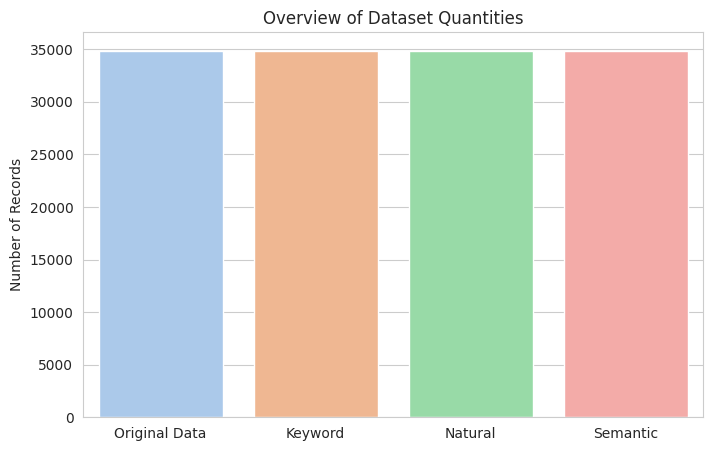

In [7]:
# Check for CSV files in the directory
csv_file = "/content/drive/MyDrive/KLTN_Project/Datasets/vifc.csv"
df_csv = pd.read_csv(csv_file)
rows = len(df_csv)
print(f"File: {csv_file} - Rows: {rows}")

print(f"\n{'='*10} OVERALL STATISTICS {'='*10}")
print(f"Total Rows:    {df_csv.shape[0]}")
print(f"Total Columns: {df_csv.shape[1]}")

print(f"\n{'='*10} COLUMN INFORMATION {'='*10}")
print(df_csv.info())

print(f"\n{'='*10} UNIQUE ELEMENTS PER COLUMN {'='*10}")
unique_counts = df_csv.nunique()
print(unique_counts)

# Visualization of dataset counts (JSONL + CSV)
counts = {
    'Original Data': rows if rows > 0 else None,
    'Keyword': len(df_keyword),
    'Natural': len(df_natural),
    'Semantic': len(df_semantic)
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='pastel')
plt.title('Overview of Dataset Quantities')
plt.ylabel('Number of Records')

save_chart('overview_counts.png')
plt.show()

# Độ dài văn bản

>> Đã lưu biểu đồ: /content/drive/MyDrive/KLTN_Project/Results/charts/length_distribution.png


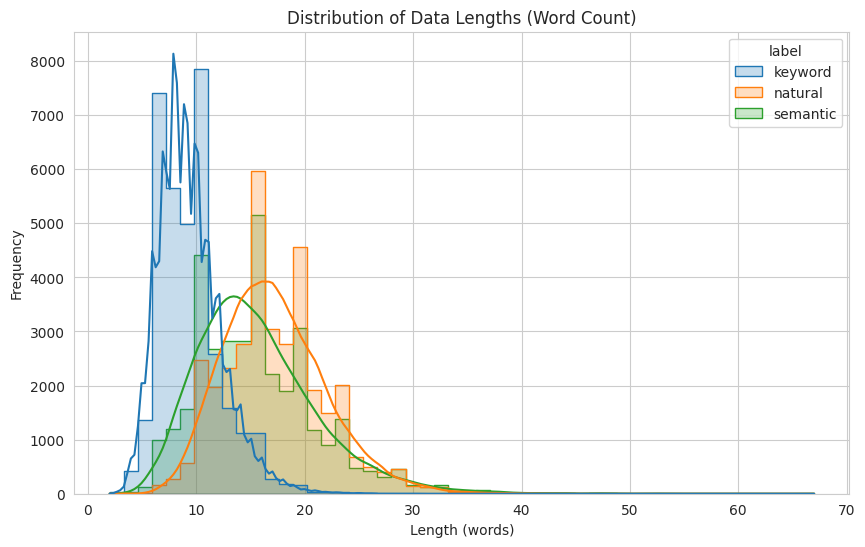

In [8]:
# Calculate length (number of words)
df_all['length'] = df_all['text'].apply(lambda x: len(x.split()))

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(data=df_all, x='length', hue='label', kde=True, element="step", bins=50)
plt.title('Distribution of Data Lengths (Word Count)')
plt.xlabel('Length (words)')
plt.ylabel('Frequency')

save_chart('length_distribution.png')
plt.show()

# Phân tích NER

In [9]:
# # Function to extract entities
# def extract_entities_heuristic(text):
#     # Extracts consecutive Capitalized Words (simple NER approximation for Vietnamese)
#     # This regex looks for words starting with Uppercase letters
#     pattern = r'\b[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐĨŨƠƯĂẠẢẤẦẨẪẬẮẰẲẴẶẸẺẼỀỀỂỄỆỈỊỌỎỐỒỔỖỘỚỜỞỠỢỤỦỨỪỬỮỰỲỴÝỶỸ][a-zàáâãèéêìíòóôõùúăđĩũơưăạảấầẩẫậắằẳẵặẹẻẽềềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵýỷỹ]*(?:\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐĨŨƠƯĂẠẢẤẦẨẪẬẮẰẲẴẶẸẺẼỀỀỂỄỆỈỊỌỎỐỒỔỖỘỚỜỞỠỢỤỦỨỪỬỮỰỲỴÝỶỸ][a-zàáâãèéêìíòóôõùúăđĩũơưăạảấầẩẫậắằẳẵặẹẻẽềềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵýỷỹ]*)*\b'
#     return re.findall(pattern, text)

from underthesea import ner

def extract_entities_underthesea(text_list):
    """
    Hàm trích xuất và ghép thực thể từ danh sách văn bản.
    Input: Danh sách các câu text.
    Output: Danh sách các tuple (Thực thể hoàn chỉnh, Loại thực thể).
    """
    all_entities = []

    print(f"Đang xử lý NER cho {len(text_list)} dòng dữ liệu...")

    for i, text in enumerate(text_list):
        if not isinstance(text, str) or not text.strip():
            continue

        try:
            # Gọi hàm ner() mặc định (không deep=True) để ra output dạng tuple
            # Output: [('word', 'pos', 'chunk', 'ner_tag'), ...]
            raw_output = ner(text)

            current_word_list = []
            current_label = None

            for token in raw_output:
                # Token là tuple 4 phần tử
                # word=token[0], pos=token[1], chunk=token[2], ner_tag=token[3]
                word = token[0]
                tag = token[3]

                if tag == 'O':
                    # Kết thúc thực thể hiện tại
                    if current_word_list:
                        full_entity = " ".join(current_word_list)
                        all_entities.append((full_entity, current_label))
                        current_word_list = []
                        current_label = None

                elif tag.startswith('B-'):
                    # Bắt đầu thực thể mới
                    if current_word_list:
                        full_entity = " ".join(current_word_list)
                        all_entities.append((full_entity, current_label))

                    current_word_list = [word]
                    current_label = tag[2:] # Lấy nhãn (VD: LOC, PER)

                elif tag.startswith('I-'):
                    # Tiếp tục thực thể (nếu nhãn khớp)
                    label_suffix = tag[2:]
                    if current_word_list and current_label == label_suffix:
                        current_word_list.append(word)
                    else:
                        # Xử lý trường hợp I- đứng đầu hoặc sai khớp (coi như bắt đầu mới)
                        if current_word_list:
                            full_entity = " ".join(current_word_list)
                            all_entities.append((full_entity, current_label))
                        current_word_list = [word]
                        current_label = label_suffix

            # Lưu thực thể cuối cùng nếu còn
            if current_word_list:
                full_entity = " ".join(current_word_list)
                all_entities.append((full_entity, current_label))

        except Exception as e:
            continue

    return all_entities

# Apply extraction
texts_to_analyze = df_all['text'].tolist()
entities_found = extract_entities_underthesea(texts_to_analyze)

Đang xử lý NER cho 104583 dòng dữ liệu...


/tmp/ipython-input-83826953.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette='viridis')


>> Đã lưu biểu đồ: /content/drive/MyDrive/KLTN_Project/Results/charts/ner_entities.png


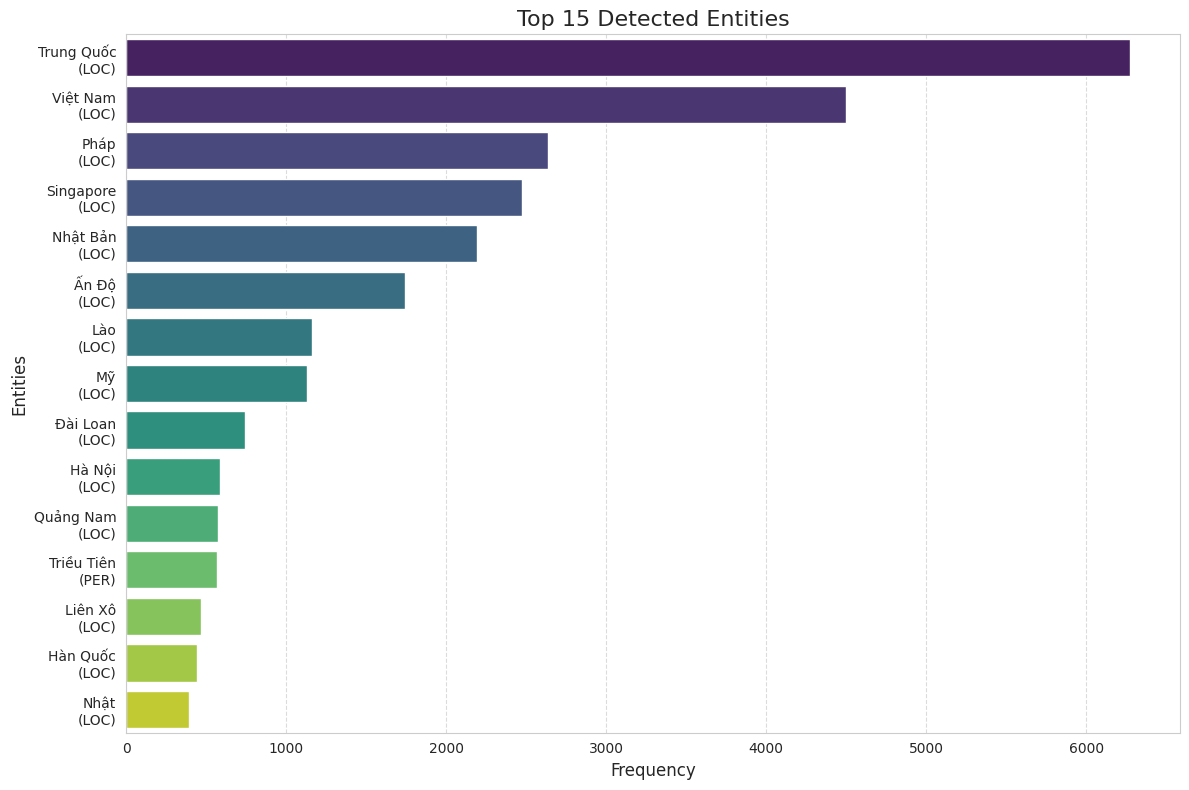


Top 5 Entities:
- Trung Quốc [LOC]: 6271
- Việt Nam [LOC]: 4500
- Pháp [LOC]: 2639
- Singapore [LOC]: 2472
- Nhật Bản [LOC]: 2190


In [10]:
# Count top entities
from collections import Counter
entity_counts = Counter(entities_found)
top_15 = entity_counts.most_common(15)

# Plot
if top_15:
    labels = [f"{item[0][0]}\n({item[0][1]})" for item in top_15]
    values = [item[1] for item in top_15]

    plt.figure(figsize=(12, 8))
    sns.barplot(x=values, y=labels, palette='viridis')
    plt.title('Top 15 Detected Entities', fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Entities', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    save_chart('ner_entities.png')
    plt.show()

    # In ra danh sách chi tiết
    print("\nTop 5 Entities:")
    for (entity, label), count in top_15[:5]:
        print(f"- {entity} [{label}]: {count}")
else:
    print("Không tìm thấy thực thể nào hoặc dữ liệu trống.")

# Wordcloud

In [11]:
VNCORE_MODEL_PATH = "/content/drive/MyDrive/KLTN_Project/Models/vncorenlp_models"
stopwords_path = "/content/drive/MyDrive/KLTN_Project/Datasets/stopwords-vi.txt"

In [12]:
import string
from typing import Set
import py_vncorenlp
from underthesea import text_normalize

class VietnameseProcessor:
    def __init__(self, vncorenlp_path: str, stopwords_path: str):
        # 1. Init VnCoreNLP
        if not os.path.exists(vncorenlp_path):
            raise FileNotFoundError(f"VnCoreNLP not found at {vncorenlp_path}")

        try:
            # Lưu ý: Cần Java cài đặt sẵn để chạy VnCoreNLP
            self.rdrsegmenter = py_vncorenlp.VnCoreNLP(
                save_dir=vncorenlp_path,
                annotators=["wseg"]
            )
        except Exception as e:
            print(f"Error init VnCoreNLP: {e}")
            # Trong môi trường notebook, ta có thể không muốn sys.exit(1) làm crash kernel
            # nên sẽ raise error để user nhận biết
            raise e

        # 2. Init Stopwords
        self.stopwords = self._load_stopwords(stopwords_path)
        self.punctuation = set(string.punctuation)

    def _load_stopwords(self, path: str) -> Set[str]:
        sw = set()
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    w = line.strip().lower()
                    if w:
                        # Chuẩn hóa format từ dừng giống output của segmenter (dùng _)
                        token = w.replace(' ', '_').replace('-', '_')
                        sw.add(token)
        return sw

    def process(self, text: str) -> str:
        """Returns a space-separated string of segmented tokens."""
        if not text: return ""
        try:
            text = text_normalize(text.lower())
        except:
            text = text.lower()

        try:
            # Segment
            sents = self.rdrsegmenter.word_segment(text)
            tokens = [t for sent in sents for t in sent.split()]
            # Filter
            valid = [t for t in tokens if t not in self.punctuation and t not in self.stopwords]
            return " ".join(valid)
        except:
            return ""

In [13]:
def generate_wordcloud_custom(dataframe, processor, label_column='label', text_column='text', save_filename='wordclouds.png'):
    if processor is None:
        print("Bỏ qua bước vẽ Wordcloud do lỗi khởi tạo Processor.")
        return

    unique_labels = dataframe[label_column].unique()
    n_labels = len(unique_labels)
    fig, axes = plt.subplots(1, n_labels, figsize=(8 * n_labels, 6))

    if n_labels == 1: axes = [axes]

    print("Đang xử lý văn bản và tạo WordCloud...")

    for i, label in enumerate(unique_labels):
        # Lấy dữ liệu theo nhãn
        subset = dataframe[dataframe[label_column] == label]

        # Gộp tất cả text của nhãn đó lại để xử lý một lần (hoặc xử lý từng dòng rồi gộp)
        # Cách tốt hơn: Xử lý từng dòng rồi gộp để tránh text quá dài gây lỗi bộ nhớ
        processed_texts = subset[text_column].astype(str).apply(processor.process)
        combined_text = " ".join(processed_texts)

        # Tạo WordCloud
        # Lưu ý: regexp=r"\S+" để bắt tất cả các token không phải khoảng trắng (bao gồm dấu _)
        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            regexp=r"\S+",
            colormap='viridis',
            max_words=100
        ).generate(combined_text)

        # Vẽ
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'WordCloud: {label.upper()}', fontsize=14)

    plt.tight_layout()

    save_chart(save_filename)
    plt.show()

Đang xử lý văn bản và tạo WordCloud...
>> Đã lưu biểu đồ: /content/drive/MyDrive/KLTN_Project/Results/charts/wordclouds.png


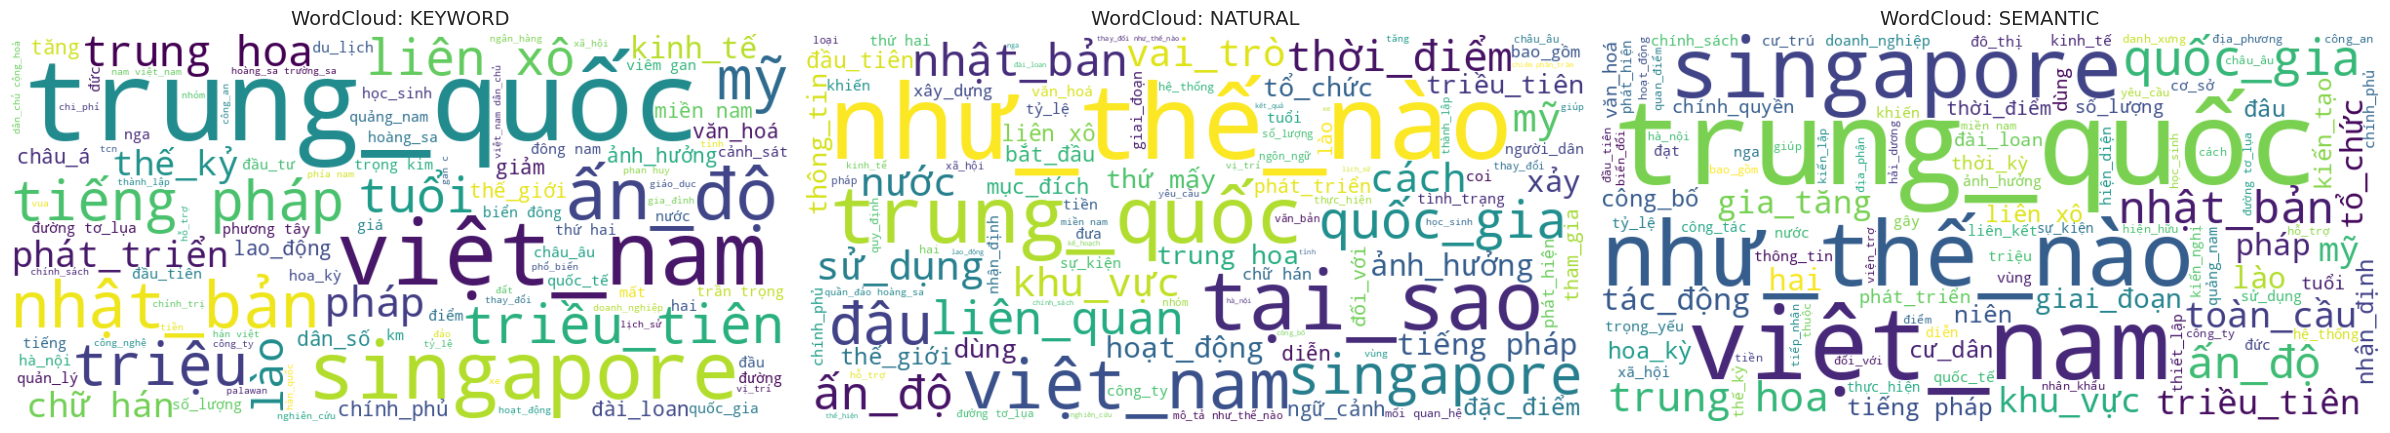

In [14]:
processor = VietnameseProcessor(VNCORE_MODEL_PATH, stopwords_path)
generate_wordcloud_custom(df_all, processor)

/tmp/ipython-input-2178990050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all[df_all['label'] != 'semantic'], x='label', y='score', palette='Set2')


>> Đã lưu biểu đồ: /content/drive/MyDrive/KLTN_Project/Results/charts/overlap_scores.png


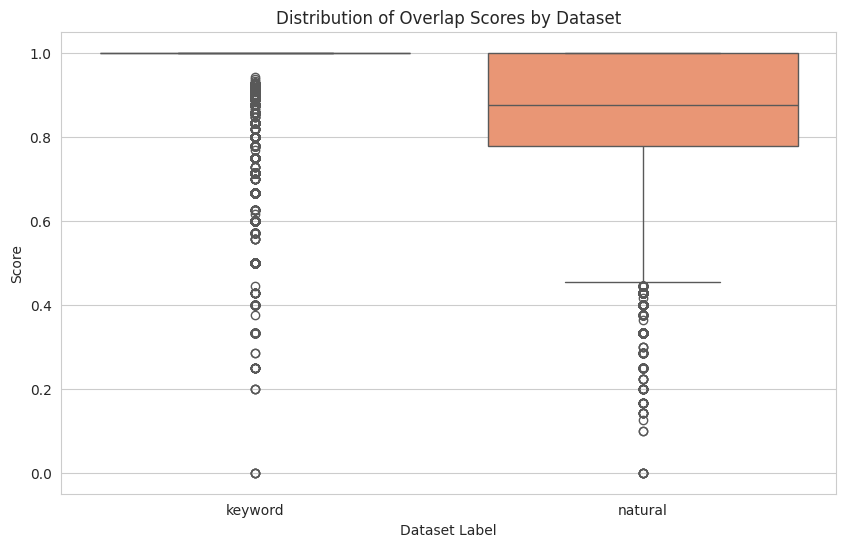

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all[df_all['label'] != 'semantic'], x='label', y='score', palette='Set2')
plt.title('Distribution of Overlap Scores by Dataset')
plt.ylabel('Score')
plt.xlabel('Dataset Label')

save_chart('overlap_scores.png')
plt.show()